# Support Vector Machines (SVM) — Complete Mathematical & Practical Guide

**Learning path:** Problem → Intuition → Geometry → Mathematics → From Scratch → Kernels → Visualization → Scikit-learn → Evaluation → Tuning → Failure Cases → Applications

This notebook connects SVM theory with practical Python, visualization, scikit-learn, and biomedical machine learning.

## 1. What problem does SVM solve?

For binary classification:

$$ (x_i,y_i),\quad y_i\in\{-1,+1\} $$

A linear classifier uses:

$$ f(x)=w^Tx+b $$

and predicts:

$$ \hat y=\operatorname{sign}(f(x)) $$

SVM searches for a separating hyperplane with a **maximum geometric margin**, rather than simply finding any separating line.

## 2. Hyperplane and margin

The decision boundary is:

$$w^Tx+b=0$$

The signed distance from $x$ to the hyperplane is:

$$\frac{w^Tx+b}{\|w\|}$$

The canonical margin boundaries are:

$$w^Tx+b=+1$$

and

$$w^Tx+b=-1$$

so the total margin width is:

$$\boxed{\frac{2}{\|w\|}}$$

Therefore maximizing the margin is equivalent to minimizing:

$$\frac12\|w\|^2$$

## 3. Hard-margin SVM

For perfectly separable data:

$$\min_{w,b}\frac12\|w\|^2$$

subject to:

$$y_i(w^Tx_i+b)\ge1$$

This formulation is elegant but unrealistic when observations overlap or contain noise.

## 4. Soft-margin SVM

Introduce slack variables $\xi_i$:

$$\min_{w,b,\xi}\frac12\|w\|^2+C\sum_i\xi_i$$

subject to:

$$y_i(w^Tx_i+b)\ge1-\xi_i,\qquad \xi_i\ge0$$

**Large $C$:** violations are strongly penalized.

**Small $C$:** more violations are tolerated and regularization is stronger.

## 5. Hinge loss

For $y\in\{-1,+1\}$:

$$L(y,f(x))=\max(0,1-yf(x))$$

Thus:

- $yf(x)\ge1$ → zero loss
- $0<yf(x)<1$ → correct but inside the margin
- $yf(x)<0$ → misclassified

The regularized objective is:

$$J=\frac12\|w\|^2+C\frac1n\sum_i\max(0,1-y_if(x_i))$$

In [3]:
# Import numerical, plotting, and machine-learning libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mglearn

from sklearn.datasets import load_breast_cancer, load_iris, make_classification
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

# Use a clean style for educational figures.
sns.set_theme(style="whitegrid", context="notebook")
np.set_printoptions(precision=4, suppress=True)

## 6. A two-dimensional example

Two dimensions make the geometry of SVM directly visible.

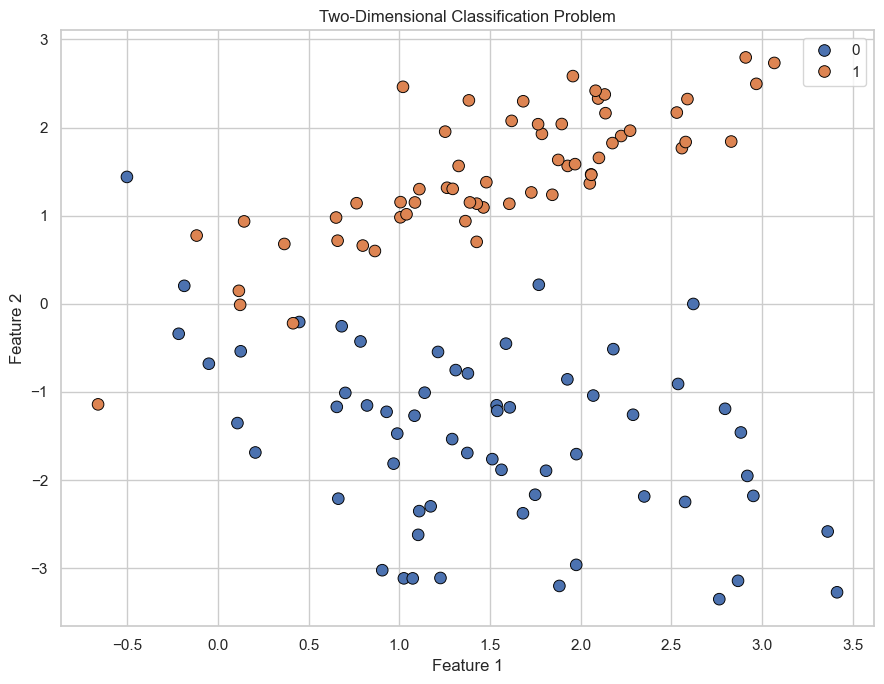

In [4]:
# Generate a reproducible two-dimensional binary classification problem.
X_demo, y_demo = make_classification(
    n_samples=120, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.6, random_state=42
)

# Convert labels from {0, 1} to {-1, +1} for the mathematical formulation.
y_signed = np.where(y_demo == 0, -1, 1)

# Plot the observations.
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_demo[:, 0], y=X_demo[:, 1], hue=y_demo,
    palette="deep", s=70, edgecolor="black"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Dimensional Classification Problem")
plt.tight_layout()
plt.show()

In [5]:
# Fit a linear SVM.
linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(X_demo, y_demo)

print("Training accuracy:", accuracy_score(y_demo, linear_svm.predict(X_demo)))
print("Weights:", linear_svm.coef_[0])
print("Bias:", linear_svm.intercept_[0])
print("Support vectors per class:", linear_svm.n_support_)

Training accuracy: 0.9583333333333334
Weights: [-0.3854  1.6615]
Bias: 0.013227439704988209
Support vectors per class: [9 9]


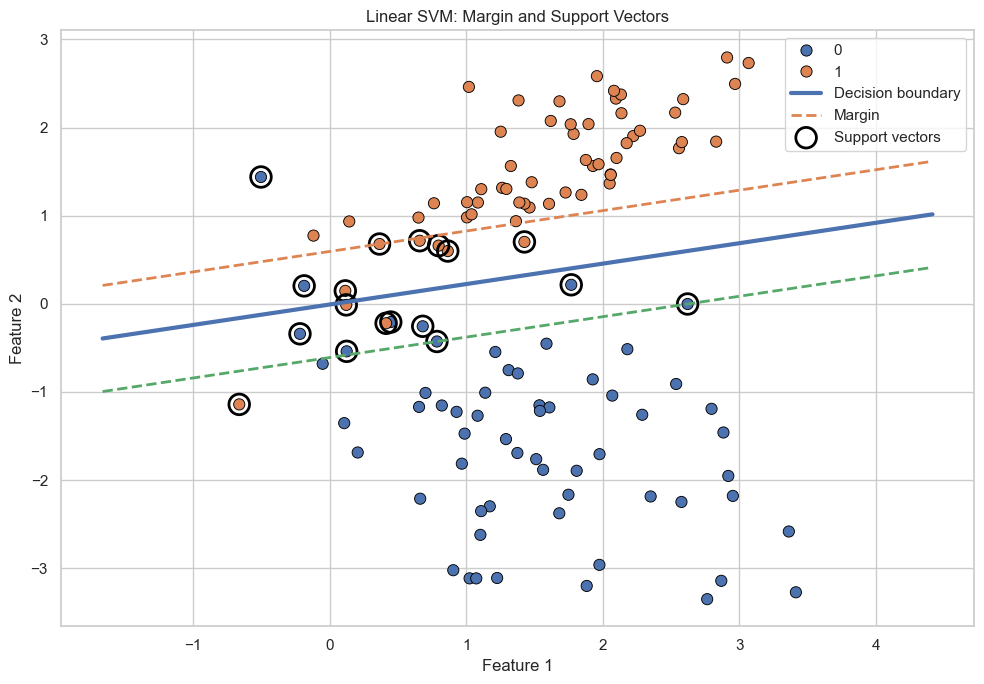

In [6]:
# Extract the learned hyperplane parameters.
w = linear_svm.coef_[0]
b = linear_svm.intercept_[0]

# Create x-coordinates for the plotted lines.
x_values = np.linspace(X_demo[:, 0].min()-1, X_demo[:, 0].max()+1, 300)

# Decision boundary: w1*x1 + w2*x2 + b = 0.
boundary = -(w[0]*x_values + b) / w[1]

# Margin boundaries: w1*x1 + w2*x2 + b = +/-1.
margin_plus = -(w[0]*x_values + b - 1) / w[1]
margin_minus = -(w[0]*x_values + b + 1) / w[1]

# Support vectors are the observations defining the margin.
sv = linear_svm.support_vectors_

# Plot data, decision boundary, margins, and support vectors.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_demo[:, 0], y=X_demo[:, 1], hue=y_demo,
    palette="deep", s=65, edgecolor="black"
)
plt.plot(x_values, boundary, linewidth=3, label="Decision boundary")
plt.plot(x_values, margin_plus, "--", linewidth=2, label="Margin")
plt.plot(x_values, margin_minus, "--", linewidth=2)
plt.scatter(
    sv[:, 0], sv[:, 1], s=220, facecolors="none",
    edgecolors="black", linewidths=2, label="Support vectors"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Linear SVM: Margin and Support Vectors")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Hinge-loss visualization

The hinge loss is:

$$\max(0,1-yf(x))$$

It becomes zero after the signed margin reaches 1.

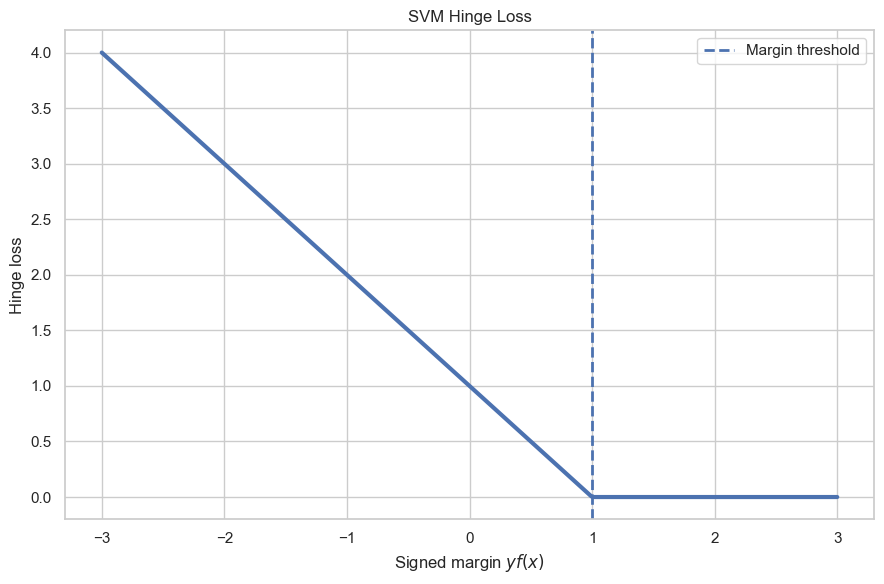

In [8]:
# Generate signed-margin values.
signed_margin = np.linspace(-3, 3, 500)

# Calculate hinge loss.
hinge = np.maximum(0, 1 - signed_margin)

# Plot the hinge-loss function.
plt.figure(figsize=(9, 6))
plt.plot(signed_margin, hinge, linewidth=3)

# Mark the margin threshold.
plt.axvline(
    1,
    linestyle="--",
    linewidth=2,
    label="Margin threshold"
)

plt.xlabel(r"Signed margin $y f(x)$")
plt.ylabel("Hinge loss")
plt.title("SVM Hinge Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Linear SVM from scratch

The following educational implementation uses subgradient descent for:

$$J=\frac12\|w\|^2+C\frac1n\sum_i\max(0,1-y_i(w^Tx_i+b))$$

It is intended to make the optimization mechanism transparent; production SVM solvers are considerably more optimized.

In [9]:
# Standardize the two-dimensional data for stable manual optimization.
X_scaled = StandardScaler().fit_transform(X_demo)

def linear_svm_from_scratch(X, y, learning_rate=0.001, C=1.0, n_iterations=4000):
    # Initialize parameters.
    w = np.zeros(X.shape[1])
    b = 0.0
    losses = []

    for _ in range(n_iterations):
        # Compute the signed margins.
        scores = X @ w + b
        margins = y * scores
        active = margins < 1

        # Gradient of the L2 regularizer.
        grad_w = w.copy()

        # Subgradient of the hinge-loss term.
        if np.any(active):
            grad_w -= C * np.mean(y[active, None] * X[active], axis=0)
            grad_b = -C * np.mean(y[active])
        else:
            grad_b = 0.0

        # Update the parameters.
        w -= learning_rate * grad_w
        b -= learning_rate * grad_b

        # Record the objective.
        new_margins = y * (X @ w + b)
        hinge = np.maximum(0, 1 - new_margins)
        losses.append(0.5*np.sum(w**2) + C*np.mean(hinge))

    return w, b, losses

scratch_w, scratch_b, losses = linear_svm_from_scratch(
    X_scaled, y_signed, learning_rate=0.001, C=1.0, n_iterations=4000
)

print("Weights:", scratch_w)
print("Bias:", scratch_b)

Weights: [0.0076 0.708 ]
Bias: 0.05696769225637377


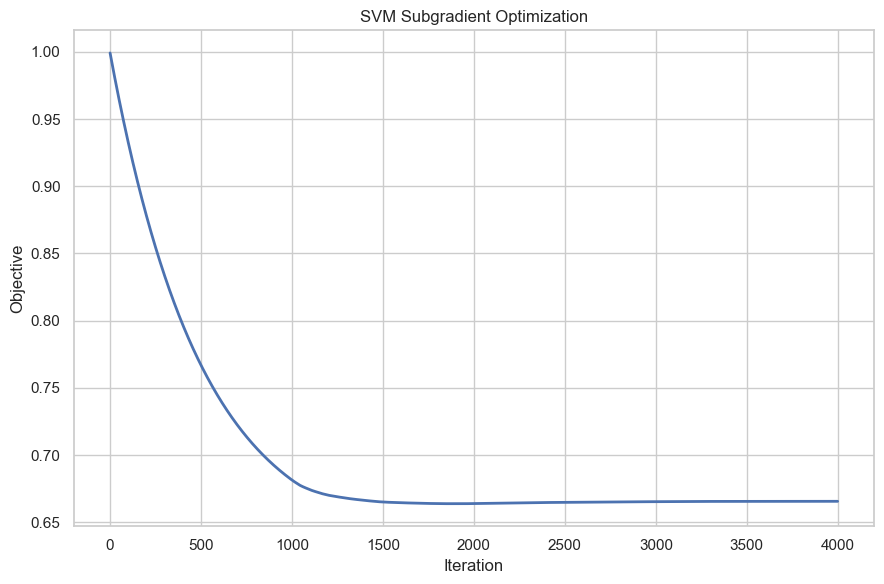

In [10]:
# Visualize optimization progress.
plt.figure(figsize=(9, 6))
plt.plot(losses, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Objective")
plt.title("SVM Subgradient Optimization")
plt.tight_layout()
plt.show()

## 9. Kernel trick

A linear boundary cannot separate every dataset.

The kernel trick computes:

$$K(x_i,x_j)=\phi(x_i)^T\phi(x_j)$$

without explicitly constructing every transformed feature.

Common kernels:
- Linear
- Polynomial
- RBF
- Sigmoid

The RBF kernel is:

$$K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$$

Small $\gamma$ gives broader influence; large $\gamma$ gives more local influence.

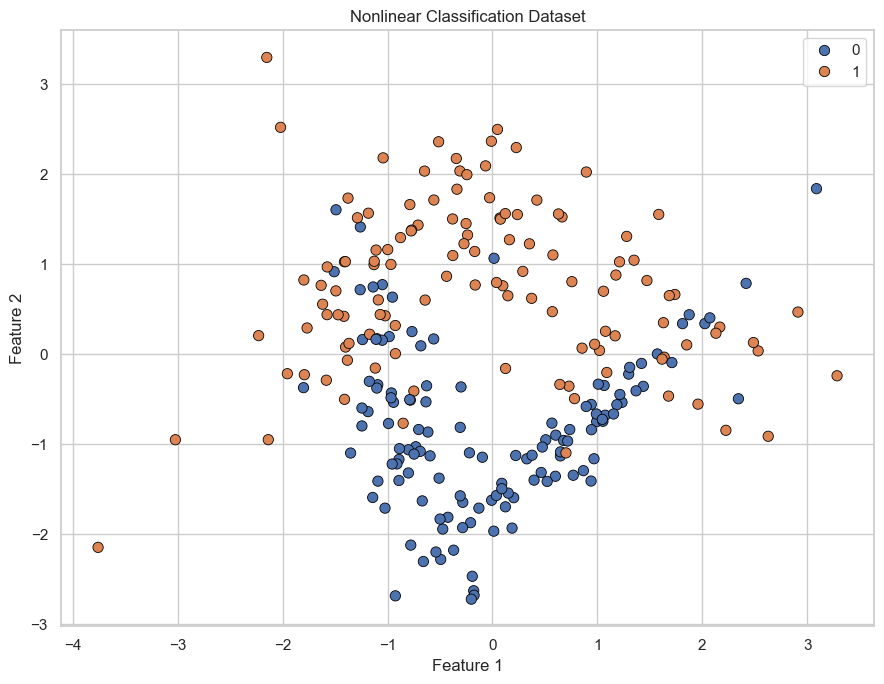

In [11]:
# Generate a nonlinear classification problem.
X_rbf, y_rbf = make_classification(
    n_samples=250, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=2,
    class_sep=0.8, flip_y=0.05, random_state=42
)

# Visualize the nonlinear data.
plt.figure(figsize=(9, 7))
sns.scatterplot(
    x=X_rbf[:, 0], y=X_rbf[:, 1], hue=y_rbf,
    palette="deep", s=55, edgecolor="black"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Classification Dataset")
plt.tight_layout()
plt.show()

In [12]:
# Put scaling inside the pipeline to prevent preprocessing leakage.
rbf_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Fit the nonlinear SVM.
rbf_svm.fit(X_rbf, y_rbf)
print("Training accuracy:", rbf_svm.score(X_rbf, y_rbf))

Training accuracy: 0.852


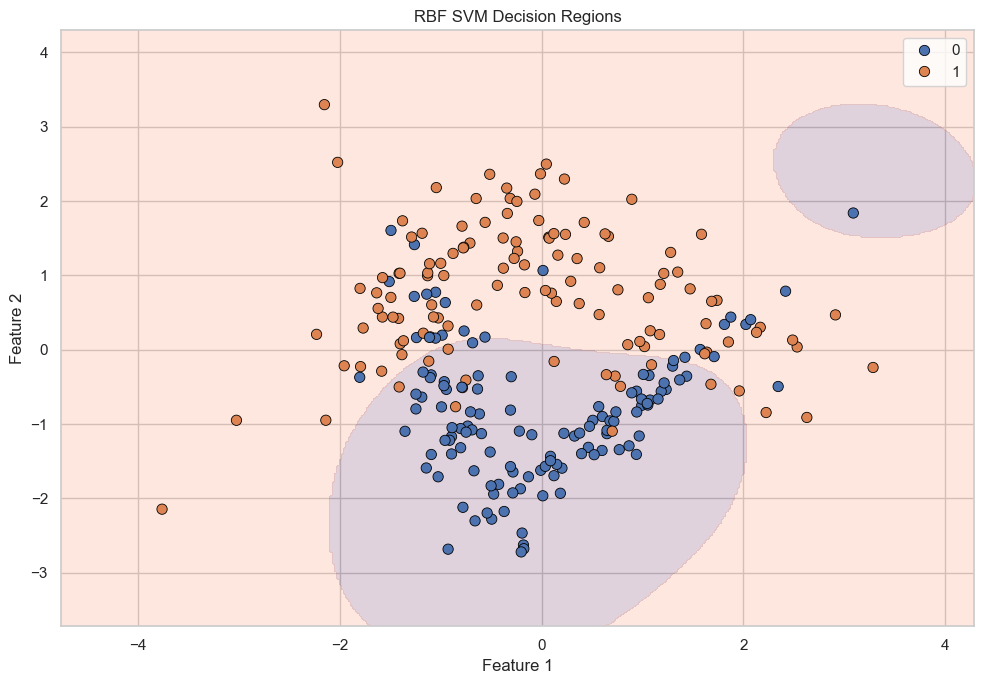

In [13]:
# Create a dense feature-space grid.
gx, gy = np.meshgrid(
    np.linspace(X_rbf[:,0].min()-1, X_rbf[:,0].max()+1, 400),
    np.linspace(X_rbf[:,1].min()-1, X_rbf[:,1].max()+1, 400)
)

# Predict each grid point to obtain decision regions.
grid_pred = rbf_svm.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)

# Plot nonlinear decision regions.
plt.figure(figsize=(10, 7))
plt.contourf(gx, gy, grid_pred, alpha=0.20, levels=1)
sns.scatterplot(
    x=X_rbf[:,0], y=X_rbf[:,1], hue=y_rbf,
    palette="deep", s=55, edgecolor="black"
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("RBF SVM Decision Regions")
plt.tight_layout()
plt.show()

## 10. Effect of $C$ and $\gamma$

Two central RBF hyperparameters:

- **$C$** controls the penalty for margin violations.
- **$\gamma$** controls how local the RBF influence is.

Both should be selected using validation rather than training performance.

In [14]:
# Compare gamma values using stratified cross-validation.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gamma_values = [0.01, 0.1, 1, 10]
gamma_results = []

for gamma in gamma_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=1.0, gamma=gamma))
    ])
    scores = cross_val_score(model, X_rbf, y_rbf, cv=cv, scoring="accuracy")
    gamma_results.append({
        "gamma": gamma,
        "mean_accuracy": scores.mean(),
        "std": scores.std()
    })

pd.DataFrame(gamma_results)

,gamma,mean_accuracy,std
0,0.01,0.796,0.054259
1,0.10,0.824,0.048000
2,1.00,0.824,0.055714
3,10.00,0.836,0.049639


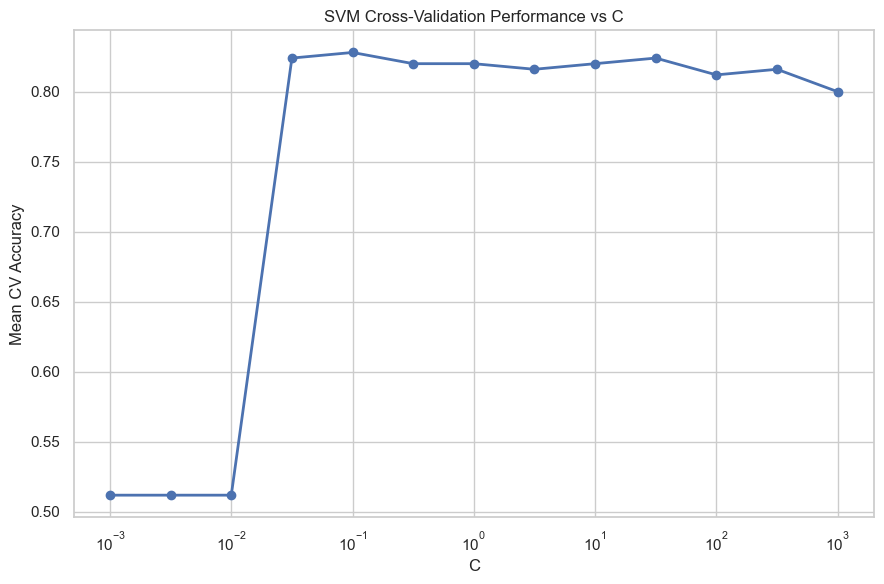

In [15]:
# Compare C values using cross-validation.
C_values = np.logspace(-3, 3, 13)
C_results = []

for C_value in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", C=C_value, gamma="scale"))
    ])
    scores = cross_val_score(model, X_rbf, y_rbf, cv=cv, scoring="accuracy")
    C_results.append({
        "C": C_value,
        "mean_accuracy": scores.mean(),
        "std": scores.std()
    })

C_df = pd.DataFrame(C_results)

plt.figure(figsize=(9, 6))
plt.semilogx(C_df["C"], C_df["mean_accuracy"], marker="o", linewidth=2)
plt.xlabel("C")
plt.ylabel("Mean CV Accuracy")
plt.title("SVM Cross-Validation Performance vs C")
plt.tight_layout()
plt.show()

## 11. Breast Cancer Wisconsin dataset

We now use a built-in scikit-learn biomedical dataset.

Default encoding:

- target `0` = malignant
- target `1` = benign

For an actual medical study, define the clinically meaningful positive class deliberately.

In [16]:
# Load the built-in Breast Cancer Wisconsin dataset.
cancer = load_breast_cancer()

X_cancer = cancer.data
y_cancer = cancer.target

print("Feature matrix:", X_cancer.shape)
print("Target:", y_cancer.shape)
print("Target names:", cancer.target_names)
print("Number of features:", len(cancer.feature_names))

# Build a DataFrame for exploration.
cancer_df = pd.DataFrame(X_cancer, columns=cancer.feature_names)
cancer_df["target"] = y_cancer
cancer_df.head()

Feature matrix: (569, 30)
Target: (569,)
Target names: ['malignant' 'benign']
Number of features: 30


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


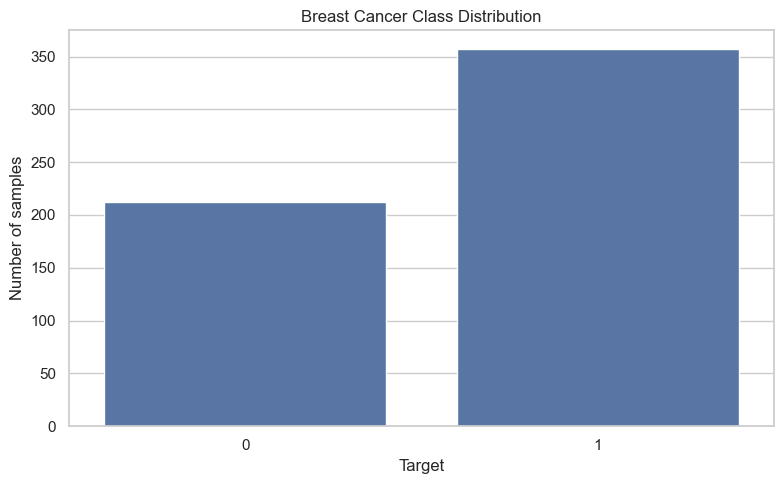

In [17]:
# Visualize the class distribution.
plt.figure(figsize=(8, 5))
sns.countplot(data=cancer_df, x="target")
plt.xlabel("Target")
plt.ylabel("Number of samples")
plt.title("Breast Cancer Class Distribution")
plt.tight_layout()
plt.show()

## 12. Leakage-safe train/test workflow

SVM is sensitive to feature scale:

$$z=\frac{x-\mu}{\sigma}$$

The scaler must be fitted using training data only. A `Pipeline` handles this correctly, including during cross-validation.

In [18]:
# Split the biomedical dataset while preserving class proportions.
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer,
    test_size=0.20,
    random_state=42,
    stratify=y_cancer
)

# Build the complete preprocessing + SVM pipeline.
cancer_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Fit only on the training set.
cancer_svm.fit(X_train, y_train)

# Generate predictions and decision scores.
y_pred = cancer_svm.predict(X_test)
y_score = cancer_svm.decision_function(X_test)

print("Test ROC-AUC:", roc_auc_score(y_test, y_score))

Test ROC-AUC: 0.9950396825396826


## 13. Evaluation metrics

Accuracy:

$$\frac{TP+TN}{TP+TN+FP+FN}$$

Precision:

$$\frac{TP}{TP+FP}$$

Recall:

$$\frac{TP}{TP+FN}$$

F1:

$$2\frac{Precision\cdot Recall}{Precision+Recall}$$

For biomedical tasks, the metric should reflect the scientific question and the cost of different errors.

In [19]:
# Calculate several standard classification metrics.
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_score)
}

pd.DataFrame(metrics.items(), columns=["Metric", "Value"])

,Metric,Value
0,Accuracy,0.982456
1,Precision,0.986111
2,Recall,0.986111
3,F1,0.986111
4,ROC-AUC,0.995040


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



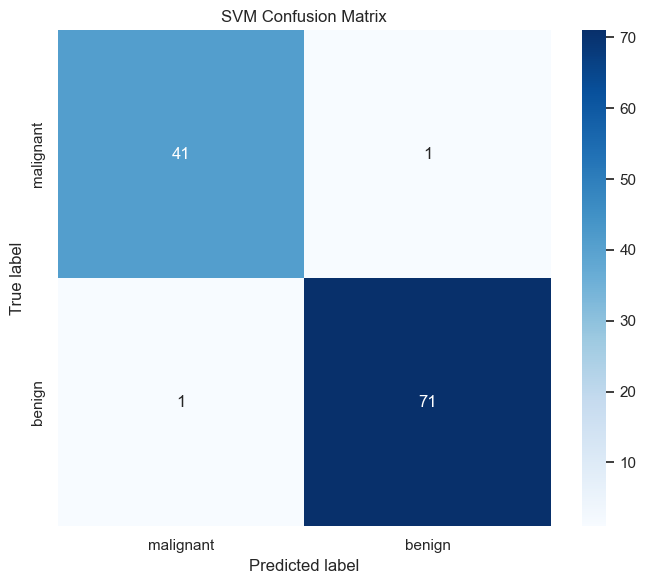

In [20]:
# Print class-wise precision, recall, F1, and support.
print(classification_report(
    y_test,
    y_pred,
    target_names=cancer.target_names
))

# Calculate and visualize the confusion matrix.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.show()

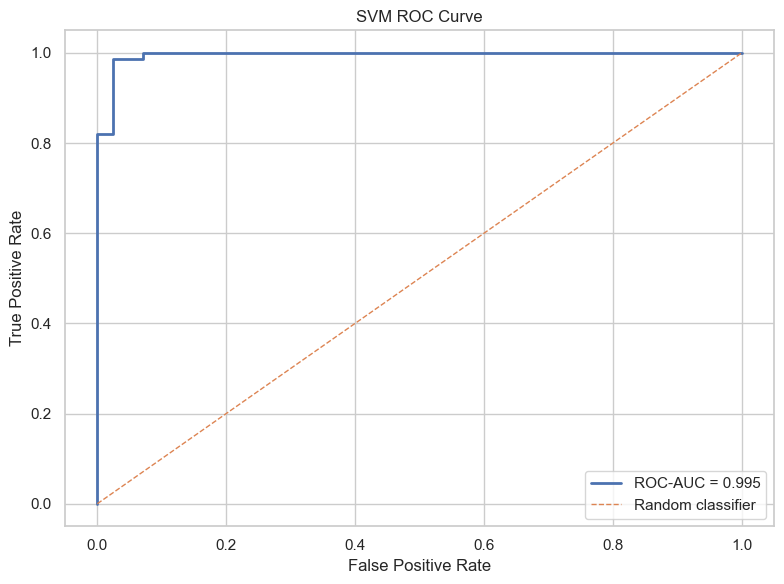

In [21]:
# Calculate ROC coordinates from the SVM decision score.
fpr, tpr, _ = roc_curve(y_test, y_score)
auc_value = roc_auc_score(y_test, y_score)

# Plot ROC curve.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {auc_value:.3f}")
plt.plot([0,1], [0,1], "--", linewidth=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

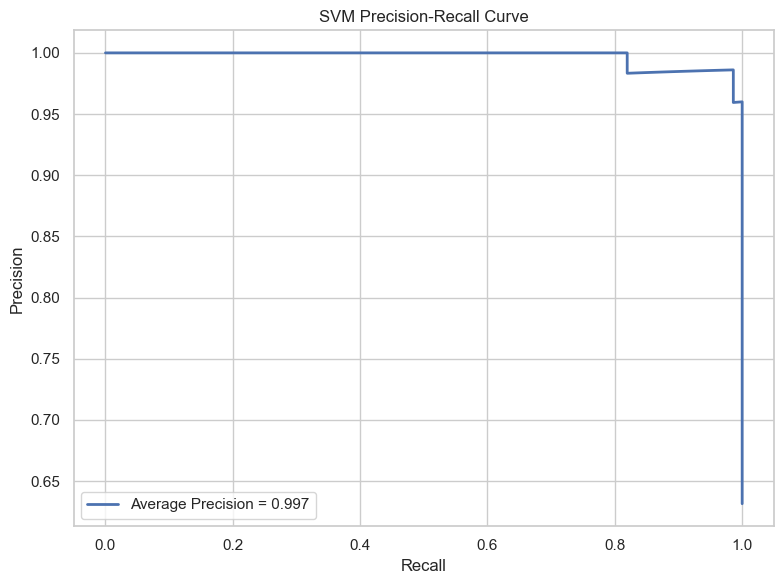

In [22]:
# Calculate and plot the Precision-Recall curve.
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, linewidth=2, label=f"Average Precision = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("SVM Precision-Recall Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Decision scores are not automatically probabilities

`SVC.decision_function()` returns signed decision scores.

If calibrated probability estimates are required:

```python
SVC(probability=True)
```

This adds computational cost and should be used only when probability estimates are actually needed.

In [23]:
# Train an SVM that exposes probability estimates.
probability_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

probability_svm.fit(X_train, y_train)

# Extract class-1 probability estimates.
probabilities = probability_svm.predict_proba(X_test)[:, 1]
print("First five probabilities:", probabilities[:5])

First five probabilities: [0.0014 1.     0.0087 0.5635 0.0062]


C:\Users\mobin\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## 15. Multiclass SVM

For $K$ classes, `SVC` uses a one-vs-one strategy.

Number of pairwise classifiers:

$$\frac{K(K-1)}2$$

For three classes, this gives three pairwise classifiers.

In [24]:
# Load and split the Iris multiclass dataset.
iris = load_iris()

X_it, X_ite, y_it, y_ite = train_test_split(
    iris.data, iris.target,
    test_size=0.20,
    random_state=42,
    stratify=iris.target
)

# Build a scaled RBF SVM.
iris_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Train and evaluate.
iris_svm.fit(X_it, y_it)
iris_pred = iris_svm.predict(X_ite)

print(classification_report(
    y_ite, iris_pred, target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 16. LinearSVC

`LinearSVC` is designed for linear classification and can be useful for high-dimensional or sparse feature spaces such as text and some genomics problems.

For nonlinear kernels, use `SVC`.

In [25]:
# Build a linear SVM pipeline.
linear_svc = Pipeline([
    ("scaler", StandardScaler()),
    ("linear_svc", LinearSVC(
        C=1.0,
        max_iter=10000,
        random_state=42
    ))
])

linear_svc.fit(X_train, y_train)
linear_pred = linear_svc.predict(X_test)

print("LinearSVC accuracy:", accuracy_score(y_test, linear_pred))

LinearSVC accuracy: 0.9649122807017544


## 17. Cross-validation and GridSearchCV

Hyperparameter selection should use training data and cross-validation.

The final test set should be evaluated **once after model selection**.

In [26]:
# Evaluate the base SVM with stratified five-fold ROC-AUC.
cv_scores = cross_val_score(
    cancer_svm,
    X_cancer,
    y_cancer,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc"
)

print("Fold ROC-AUC:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

Fold ROC-AUC: [0.9997 0.9898 0.9851 1.     0.998 ]
Mean: 0.9945250963143201
Std: 0.005980438991274852


In [27]:
# Define a pipeline for hyperparameter search.
search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

# Search both RBF and linear SVM configurations.
param_grid = [
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", 0.001, 0.01, 0.1]
    },
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100]
    }
]

grid = GridSearchCV(
    search_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True
)

# Fit the search only on training data.
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# Evaluate the selected model on the untouched test set.
best_score = grid.best_estimator_.decision_function(X_test)
print("Final test ROC-AUC:", roc_auc_score(y_test, best_score))

Best parameters: {'svc__C': 10, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
Best CV ROC-AUC: 0.9963880288957689
Final test ROC-AUC: 0.9976851851851851


## 18. Support-vector diagnostics

The number of support vectors is useful diagnostic information, but it is **not a model-quality score**.

Interpret it together with validation performance, test performance, dataset size, class overlap, and model complexity.

In [28]:
# Fit an RBF SVM and inspect support-vector counts.
support_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

support_model.fit(X_train, y_train)

fitted_svc = support_model.named_steps["svc"]

print("Support vectors per class:", fitted_svc.n_support_)
print("Total support vectors:", len(fitted_svc.support_))

Support vectors per class: [51 46]
Total support vectors: 97


## 19. Class imbalance

When one class is much more common than another, accuracy can become misleading.

SVM provides:

```python
class_weight="balanced"
```

which increases the optimization weight of minority classes.

Always compare metrics such as Recall, Precision, F1, ROC-AUC, and PR-AUC according to the scientific objective.

In [29]:
# Create a deliberately imbalanced binary classification dataset.
X_imb, y_imb = make_classification(
    n_samples=1200,
    n_features=10,
    n_informative=5,
    n_redundant=1,
    weights=[0.90, 0.10],
    random_state=42
)

# Split while preserving the imbalance.
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imb, y_imb,
    test_size=0.20,
    random_state=42,
    stratify=y_imb
)

# Standard SVM.
standard = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

# Class-balanced SVM.
balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced"
    ))
])

standard.fit(Xi_train, yi_train)
balanced.fit(Xi_train, yi_train)

p_standard = standard.predict(Xi_test)
p_balanced = balanced.predict(Xi_test)

pd.DataFrame({
    "Model": ["Standard SVM", "Balanced SVM"],
    "Precision": [
        precision_score(yi_test, p_standard),
        precision_score(yi_test, p_balanced)
    ],
    "Recall": [
        recall_score(yi_test, p_standard),
        recall_score(yi_test, p_balanced)
    ],
    "F1": [
        f1_score(yi_test, p_standard),
        f1_score(yi_test, p_balanced)
    ]
})

,Model,Precision,Recall,F1
0,Standard SVM,0.769231,0.4,0.526316
1,Balanced SVM,0.625000,0.8,0.701754


## 20. Common SVM failure modes

1. **No feature scaling** — geometry becomes dominated by large-scale variables.
2. **Data leakage** — preprocessing is learned before the train/test split.
3. **Tuning on the test set** — produces an optimistic estimate.
4. **Very large gamma** — can create overly local boundaries.
5. **Very large C** — can strongly fit difficult observations.
6. **Kernel SVM on huge datasets** — computational cost can become substantial.
7. **Accuracy-only evaluation** — may hide minority-class errors.
8. **Confusing decision scores with probabilities** — `decision_function()` is not calibrated probability.


## 21. SVM vs Logistic Regression

| Property | Logistic Regression | SVM |
|---|---|---|
| Main objective | Log-loss / likelihood | Margin + hinge loss |
| Linear boundary | Yes | Yes |
| Nonlinear kernels | No | Yes |
| Support vectors | No | Yes |
| Natural probability model | Yes | No |
| Important scaling | Yes | Usually very important |
| High-dimensional linear data | Strong | Strong with LinearSVC |
| Nonlinear modeling | Feature engineering | Kernel functions |

The two algorithms may produce similar boundaries on some datasets, but their optimization objectives are fundamentally different.

## 22. SVM in Bioinformatics and Medical AI

SVM is often useful as a feature-based baseline when the dataset has moderate sample size and potentially high-dimensional features.

Applications include:

- gene-expression classification
- cancer subtype classification
- mutation-status prediction
- radiomics
- pathology-derived features
- protein/sequence classification
- biomarker classification

A typical radiomics workflow is:

$$
MRI\rightarrow Segmentation\rightarrow Feature\ Extraction
\rightarrow Feature\ Selection\rightarrow Scaling\rightarrow SVM
$$

For biomedical research, patient-level splitting, leakage prevention, appropriate cross-validation, and external validation are critical.

## 23. Final workflow

```text
Define scientific question
        ↓
Define target
        ↓
Split patients/samples correctly
        ↓
Build preprocessing Pipeline
        ↓
Train Linear SVM baseline
        ↓
Try nonlinear SVM when justified
        ↓
Tune C and gamma with CV
        ↓
Evaluate on untouched test data
        ↓
Analyze errors and support vectors
        ↓
Perform external validation
        ↓
Report limitations
```

### Core equations

Decision function:

$$f(x)=w^Tx+b$$

Margin:

$$\frac{2}{\|w\|}$$

Hinge loss:

$$\max(0,1-yf(x))$$

RBF kernel:

$$K(x_i,x_j)=\exp(-\gamma\|x_i-x_j\|^2)$$

### Core lesson

**SVM = Geometry + Margin + Support Vectors + Hinge Loss + Regularization + Kernels + Careful Validation**

## References

- Scikit-learn — Support Vector Machines documentation
- Hastie, Tibshirani & Friedman — *The Elements of Statistical Learning*
- James, Witten, Hastie & Tibshirani — *An Introduction to Statistical Learning*
- Bishop — *Pattern Recognition and Machine Learning*
- Cortes & Vapnik — *Support-Vector Networks*
- Pedregosa et al. — *Scikit-learn: Machine Learning in Python*

Always verify behavior against the installed versions of your libraries when reproducing research or teaching code.